In [19]:
import piplite

In [20]:
await piplite.install('pandas')

In [21]:
import pandas as pd

In [22]:
df=pd.read_csv("healthcare_patient_analytics.csv")

In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5003 entries, 0 to 5002
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           5003 non-null   int64  
 1   visit_date           5003 non-null   str    
 2   age_group            5003 non-null   str    
 3   gender               5003 non-null   str    
 4   region               5003 non-null   str    
 5   department           5003 non-null   str    
 6   treatment_type       5003 non-null   str    
 7   visit_type           5003 non-null   str    
 8   length_of_stay_days  5003 non-null   float64
 9   treatment_cost       5003 non-null   int64  
 10  recovery_score       5003 non-null   int64  
 11  readmission_risk     5003 non-null   float64
dtypes: float64(2), int64(3), str(7)
memory usage: 332.3 KB


In [24]:
df.shape

(5003, 12)

In [25]:
df.head()

,patient_id,visit_date,age_group,gender,region,department,treatment_type,visit_type,length_of_stay_days,treatment_cost,recovery_score,readmission_risk
0,1,01-01-2022 00:00,31-45,Male,West,General Medicine,Medication,Emergency,50.0,59151,59,0.12
1,2,01-01-2022 01:00,60+,Female,West,Orthopedics,Surgery,Routine,5.1,30272,97,0.11
2,3,01-01-2022 02:00,46-60,Male,South,Pediatrics,Observation,Routine,7.9,67498,60,0.19
3,4,01-01-2022 03:00,31-45,Female,North,Neurology,Medication,Routine,5.0,29896,51,0.47
4,5,01-01-2022 04:00,18-30,Female,North,Neurology,Therapy,Routine,0.0,36208,60,0.40


In [9]:
print("Number of missing values: ", df.isnull().sum())

Number of missing values:  patient_id             0
visit_date             0
age_group              0
gender                 0
region                 0
department             0
treatment_type         0
visit_type             0
length_of_stay_days    0
treatment_cost         0
recovery_score         0
readmission_risk       0
dtype: int64


In [27]:
print("Duplicates", df.duplicated().sum())

Duplicates 3


In [28]:
df.drop_duplicates(inplace=True)

In [29]:
print("Duplicate rows after removal:", df.duplicated().sum())
df.shape

Duplicate rows after removal: 0


(5000, 12)

In [30]:
df["visit_date"] = pd.to_datetime(df["visit_date"], format='mixed', dayfirst=True)

In [31]:
print(df.describe())

        patient_id           visit_date  length_of_stay_days  treatment_cost  \
count  5000.000000                 5000          5000.000000     5000.000000   
mean   2500.500000  2022-04-15 03:30:00             4.068500    54915.471800   
min       1.000000  2022-01-01 00:00:00             0.000000      746.000000   
25%    1250.750000  2022-02-22 01:45:00             2.700000    41244.750000   
50%    2500.500000  2022-04-15 03:30:00             4.000000    55123.500000   
75%    3750.250000  2022-06-06 05:15:00             5.400000    68012.000000   
max    5000.000000  2022-07-28 07:00:00            50.000000   119307.000000   
std    1443.520003                  NaN             2.035179    19481.160487   

       recovery_score  readmission_risk  
count     5000.000000       5000.000000  
mean        74.718800          0.280966  
min         33.000000          0.010000  
25%         67.000000          0.160000  
50%         75.000000          0.260000  
75%         83.000000      

In [32]:
negative_costs = df[df["treatment_cost"] < 0]

if negative_costs.empty:
    print("No negative treatment costs found.")
else:
    print("Negative treatment costs found:")
    print(negative_costs)

No negative treatment costs found.


In [33]:
negative_costs = df[df["treatment_cost"] < 0]
print(negative_costs)

Empty DataFrame
Columns: [patient_id, visit_date, age_group, gender, region, department, treatment_type, visit_type, length_of_stay_days, treatment_cost, recovery_score, readmission_risk]
Index: []


In [18]:
print("Total records:", len(df))
print("Unique patients:", df["patient_id"].nunique())


Total records: 5000
Unique patients: 5000


In [34]:
unusual_stays = df[df["length_of_stay_days"] > 30]
print("Number of unusual stays:", len(unusual_stays))
unusual_stays

Number of unusual stays: 1


,patient_id,visit_date,age_group,gender,region,department,treatment_type,visit_type,length_of_stay_days,treatment_cost,recovery_score,readmission_risk
0,1,2022-01-01,31-45,Male,West,General Medicine,Medication,Emergency,50.0,59151,59,0.12


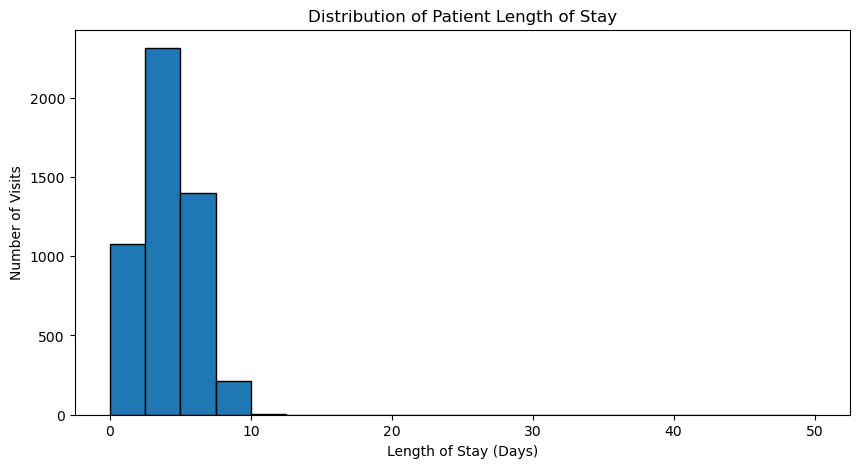

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    df["length_of_stay_days"],
    bins=20,
    edgecolor="black"
)

plt.xlabel("Length of Stay (Days)")
plt.ylabel("Number of Visits")
plt.title("Distribution of Patient Length of Stay")

plt.show()


In [48]:
df["los_outlier_flag"] = df["length_of_stay_days"] > 30

print(
    df["los_outlier_flag"].value_counts()
)


los_outlier_flag
False    4999
True        1
Name: count, dtype: int64


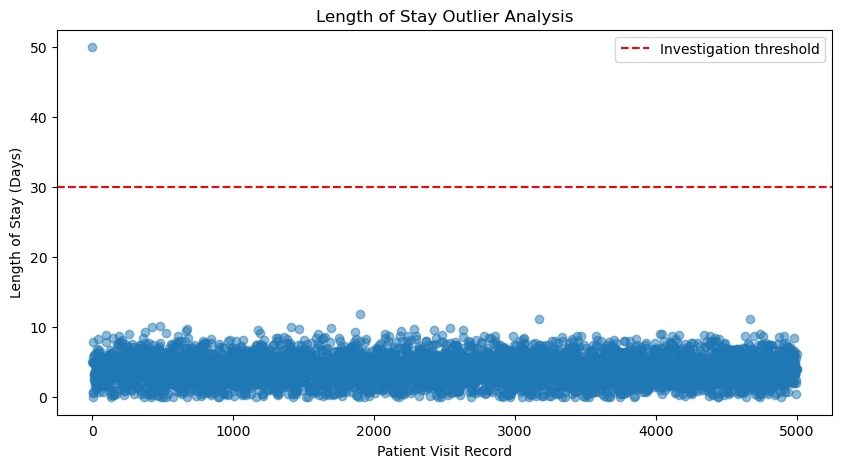

In [49]:
plt.figure(figsize=(10, 5))

plt.scatter(
    range(len(df)),
    df["length_of_stay_days"],
    alpha=0.5
)

plt.axhline(
     y=30,
    color="red",
    linestyle="--",
    label="Investigation threshold"
)

plt.xlabel("Patient Visit Record")
plt.ylabel("Length of Stay (Days)")
plt.title("Length of Stay Outlier Analysis")
plt.legend()

plt.show()
